# Vehicle dataset
This dataset contains info's about used cars. We will use it to predict prices.

The columns are as given:
1. name
2. year
3. selling_price
4. km_driven
5. fuel
6. seller_type
7. transmission
8. Owner

## 1. Get the data

In [63]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt

In [64]:
!kaggle datasets download -d nehalbirla/vehicle-dataset-from-cardekho

Dataset URL: https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho
License(s): DbCL-1.0
vehicle-dataset-from-cardekho.zip: Skipping, found more recently modified local copy (use --force to force download)


In [65]:
#!unzip vehicle-dataset-from-cardekho.zip
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## 2. Inspect the data
Before we start training our model, let's have a first look:

In [66]:
# Get a first glimpse
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


`info()` gives us the following insights:
1. Shape is 301 rows and 9 columns
2. Index column are just numbers 0 - 300
3. `Owner` is not in the correct type. Other columns are already in the correct datatypes. We have 2x float64, 3x int64 and 4x object columns.
4. No missing values in the dataset

We can continue and display the numerical features:

In [67]:
# Summary statistics
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


`describe()` gives further insights in the mean/median, range (min/ max) and dispersion (standard deviation, quartiles):
1. Cars start at year 2003 - 25% of the cars are under year 2012 and the rest is between 2012 and 2018
2. Selling Price has an average of 4.66 - we need to figure out if this figure is in USD and in thousands
3. Same applies for Present Price. The general present price seems to be higher than the selling price
4. We have cars which drove between 500 and 500k kilometres. This upper limit seems to be capped.
5. Our cars had an average of 0 owners and max are 3. We need to investigate what 0 owners means.

Let's have a closer look at the categorical columns - we will need to further investigate column `Owner` in the EDA:

In [68]:
# We only need the columns type 'object'
columns = list(df.select_dtypes('object').columns)
for col in columns:
    print(f"Column: {col}")
    print(df[col].value_counts())
    print("\n\n")

Column: Car_Name
Car_Name
city                        26
corolla altis               16
verna                       14
fortuner                    11
brio                        10
                            ..
Honda CB Trigger             1
Yamaha FZ S                  1
Bajaj Pulsar 135 LS          1
Activa 4g                    1
Bajaj Avenger Street 220     1
Name: count, Length: 98, dtype: int64



Column: Fuel_Type
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64



Column: Seller_Type
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64



Column: Transmission
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64





Some of the car names are a bit off - but we can drop this column later anyways as our model won't gain any knowledge from this predictor. The other categorical columns seem correct, none are missing.

Let's explore the distribution and skewness of all numerical features:

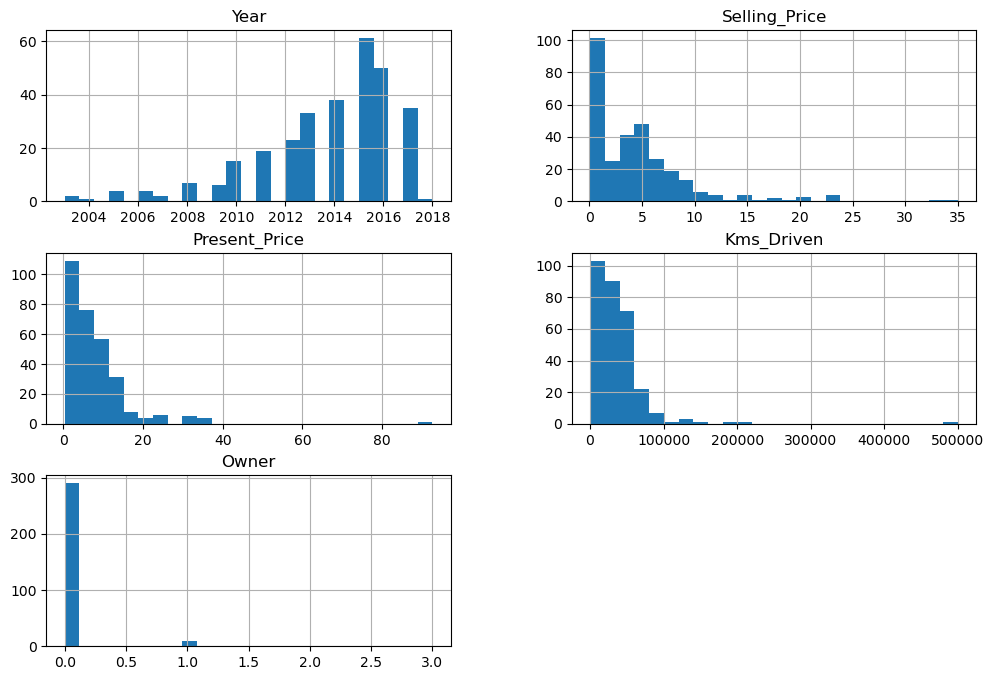

In [69]:
df.select_dtypes('number').hist(bins=25, figsize=(12,8))
plt.show()

The histogram emphasises the following:
1. Most cars are from the year 2015 - the data is slightly left skewed
2. Selling Price is in thousands $ and right-skewed - some outliers are visible around the 34-35k mark
3. Present Price is generally higher, also in $ thousands and we can identify a heavy outlier at 90k$
4. kms driven is mainly between 0 and 100k. A few cars are between 100k-200k and an outlier is visible at 500k
5. Owners seem to not have much value for our ML algorithm. Most cars have 0 owners, maybe 10 cars had 1 owner and 1 car had 3 owners

## 3. Create a Test set
After some initial exploration of what we are dealing with - let's create a test set, copy it and perform EDA on the copy.

In [70]:
from sklearn.model_selection import train_test_split
df_train_set, df_test_set = train_test_split(df, test_size=0.2, random_state=42)
cars = df_train_set.copy()

### 3.1 Relationship of multiple features
Let's have a look at the relationship of two continuous features - `present_price` vs `kms_driven`, colored by `fuel_type`.

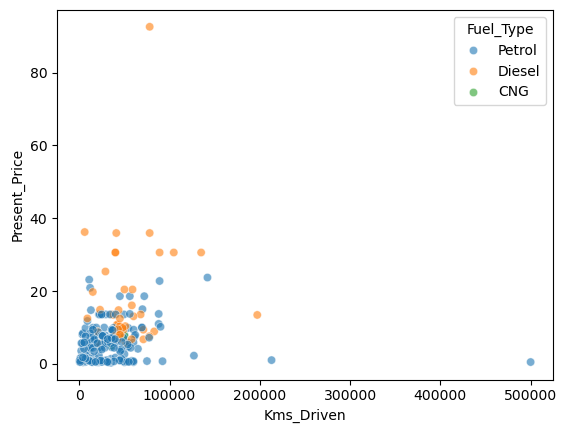

In [71]:
sns.scatterplot(data = cars, x = 'Kms_Driven', y='Present_Price', hue='Fuel_Type', alpha = 0.6)
plt.show()

The scatterplot reveals most of the cars are powered by diesel or petrol. Diesel cars seem to have a higher average `present_price`. We can also see that there are two outliers. One diesel car which is valued at 90k and one petrol car which has been drive 500_000 kilometers. We can further investigate the relationship of those three variables using grouped summary statistics:

In [93]:
wide_sum_stats = cars[['Fuel_Type','Present_Price','Kms_Driven']].groupby("Fuel_Type").agg(["mean","median","std"])
long_sum_stats = wide_sum_stats.stack(level=1).reset_index()
long_sum_stats.rename(columns = {"level_1":'statistics'}, inplace=True)
long_sum_stats

/var/folders/bh/_p1bkhtn09b6syd7vz5f61pw0000gn/T/ipykernel_13432/4056651951.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  long_sum_stats = wide_sum_stats.stack(level=1).reset_index()


,Fuel_Type,statistics,Present_Price,Kms_Driven
0,CNG,mean,6.415000,42749.000000
1,CNG,median,6.415000,42749.000000
2,CNG,std,1.873833,10251.634114
3,Diesel,mean,16.889556,53934.911111
4,Diesel,median,12.480000,45000.000000
5,Diesel,std,14.828628,32549.997402
6,Petrol,mean,5.336907,33624.274611
7,Petrol,median,4.430000,25000.000000
8,Petrol,std,4.985499,43108.679650


The table reveals that Diesel cars are indeed more expensive than Petrol cars, even though they average a higher amount of total kms_driven.

### 3.2 Looking for Correlations
Next, we further explore the dataset to identify whether any predictors show a correlation with the target variable. We also examine whether any predictor are correlated with each other, as strong correlations between predictors may leaed to multicollinearity.

In [97]:
corr_matrix = cars.corr(numeric_only=True)
corr_matrix['Present_Price'].sort_values(ascending=False)

Present_Price    1.000000
Selling_Price    0.889505
Kms_Driven       0.185208
Owner            0.023516
Year            -0.035695
Name: Present_Price, dtype: float64

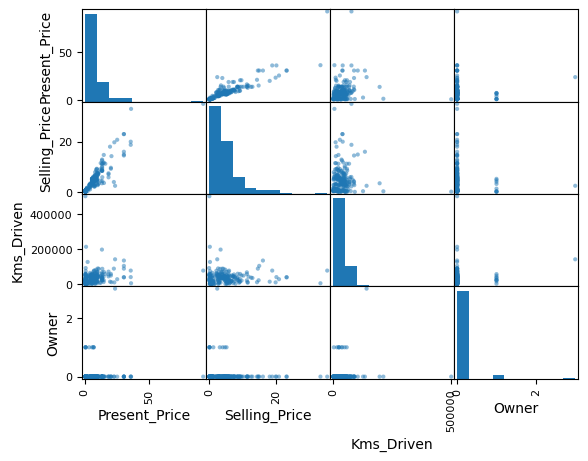

In [104]:
# We can also visualise the 5 variables
from pandas.plotting import scatter_matrix

# Exclude year
attributes=['Present_Price','Selling_Price','Kms_Driven','Owner']
scatter_matrix(cars[attributes])
plt.show()

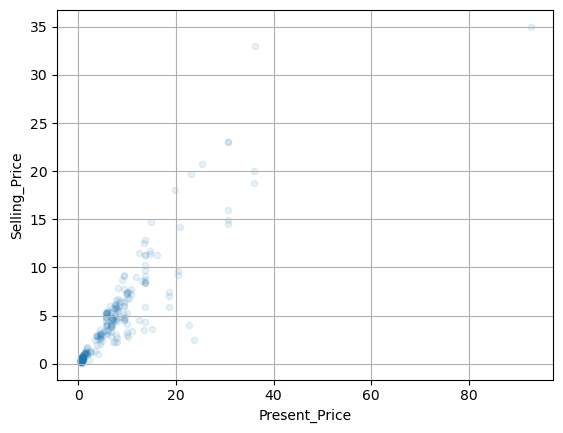

In [107]:
cars.plot(kind='scatter', x='Present_Price',y='Selling_Price', alpha=0.1, grid=True)
plt.show()

We can see that the previous present price is a strong indicator for the current price.

## 4. Prepare the Data for Machine Learning Algorithms
We will start the data preparation by separating our labels from the target:

In [112]:
cars = df_train_set.drop('Selling_Price',axis=1)
cars_labels = df_train_set['Selling_Price'].copy()

### Data Cleaning
We will check here if our data has any missing values:

In [114]:
cars.isna().sum()

Car_Name         0
Year             0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

No missing values are given, but if we had some `NaN` values there are three options to handle them:

In [ ]:
'''
cars.dropna(subset = ['columns_with_missing_values'], axis = 1, inplace=True) # Option 1: We would drop the rows with NaN
cars.drop('columns_with_missing_values', axis = 1, inplace = 1) # Option 2: Drop the whole column with missing values
# Option 3: Impute NaN with median value (or mean, mode, ffill, ..)
median = cars['columns_with_missing_values'].median()
cars['columns_with_missing_values'] = cars['columns_with_missing_values'].fillna(median)
'''
pass # Skip this cell - code only an FYI

Preferred option would be the imputation by using `sklearn.impute.SimpleImputer`.

### Data Outliers
Data outliers can affect various machine learning algorithms. We need to see if they are an error or maybe a rare measurement. First, let's identify an outlier:

In [159]:
lower_quantile = df.select_dtypes('number').quantile(0.25)
upper_quantile = df.select_dtypes('number').quantile(0.75)

iqr = upper_quantile - lower_quantile
lower_limit = lower_quantile - iqr * 1.5
upper_limit = upper_quantile + iqr * 1.5

# Filter outliers
outliers = (
    (df.select_dtypes('number') < lower_limit) |
    (df.select_dtypes('number') > upper_limit)
)
outliers_rows = outliers.any(axis=1)

# Show the dataframe with rows containing outliers
cars[outliers_rows].head()

/var/folders/bh/_p1bkhtn09b6syd7vz5f61pw0000gn/T/ipykernel_13432/2348143226.py:16: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  cars[outliers_rows].head()


,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
184,Bajaj Pulsar 150,2008,0.75,26000,Petrol,Individual,Manual,1
59,fortuner,2014,35.96,41000,Diesel,Dealer,Automatic,0
93,fortuner,2015,30.61,40000,Diesel,Dealer,Automatic,0
84,innova,2005,13.46,197176,Diesel,Dealer,Manual,0
66,innova,2017,23.15,11000,Petrol,Dealer,Automatic,0


#### Detect outliers for TWO column

In [161]:
cols = ['Kms_Driven', 'Present_Price']

outliers_values = cars[cols].where(
    (cars[cols] < lower_limit[cols]) |
    (cars[cols] > upper_limit[cols])
)
outliers_values.dropna(how='all') # Only keeps the outliers

,Kms_Driven,Present_Price
59,NaN,35.96
93,NaN,30.61
84,197176.0,NaN
66,NaN,23.15
79,NaN,30.61
196,500000.0,NaN
37,127000.0,NaN
96,NaN,25.39
86,NaN,92.60
179,213000.0,NaN


We will keep the outliers, even the 500k km row - as the car is old and the present price 520US$:

In [ ]:
# Show this one row
cars[cars['Kms_Driven'] > 499999]

,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
196,Activa 3g,2008,0.52,500000,Petrol,Individual,Automatic,0
